# 02 · Modelo baseline econométrico

**Proyecto:** Market Value Dynamics & Inefficiency in European Football Transfers  
**Fase:** Modelización  
**Unidad de análisis:** jugador-temporada  
**Target:** `log_market_value_eur`  
**Objetivo:** estimar el valor de mercado esperado de cada jugador y derivar una primera medida de ineficiencia de mercado.

---

## Propósito del notebook

Este notebook construye el primer modelo econométrico del proyecto. Su función no es maximizar rendimiento predictivo desde el primer intento, sino establecer un **baseline interpretable, replicable y defendible académicamente**.

El modelo baseline permite:

1. Estimar el valor esperado de mercado condicionado a edad, minutos, rendimiento y contexto competitivo.
2. Evaluar qué variables explican mejor la variación del valor de mercado.
3. Generar residuos económicos interpretables.
4. Construir una primera versión del `Inefficiency Score`.
5. Preparar una referencia frente a modelos más complejos de machine learning.

Desde el punto de vista metodológico, este notebook cubre la fase de **Modelización**: selección de técnica, diseño de evaluación, construcción del modelo y evaluación preliminar de resultados.

## 0. Hipótesis econométrica del baseline

La hipótesis de partida es que el valor de mercado observado de un jugador puede aproximarse mediante una función de:

- características demográficas: edad y ciclo de vida deportivo;
- participación competitiva: minutos jugados;
- rendimiento deportivo: índices de finalización, creación, progresión y defensa;
- contexto: posición, liga y temporada;
- calidad del registro: confianza del matching y banderas de muestra reducida.

La especificación principal es log-lineal:

$$
\log(MV_{i,t}) = \beta_0 + \beta_1 Age_{i,t} + \beta_2 Age^2_{i,t} + \beta_3 \log(1 + Minutes_{i,t}) + \beta_4 Performance_{i,t} + \gamma_p + \delta_l + \tau_t + \epsilon_{i,t}
$$

Donde:

- $i$ representa el jugador;
- $t$ representa la temporada;
- $\gamma_p$ recoge efectos fijos de posición;
- $\delta_l$ recoge efectos fijos de liga;
- $\tau_t$ recoge efectos fijos temporales;
- $\epsilon_{i,t}$ es el componente no explicado por el modelo.

La diferencia entre el valor estimado y el valor observado se interpreta como una medida de desviación relativa frente al mercado.

In [1]:
# ============================================================
# 1. Imports y configuración general
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# El notebook está pensado para ejecutarse desde /notebooks o desde la raíz del repositorio.
CWD = Path.cwd()
ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DATA_PATH = ROOT / "data" / "processed" / "player_season_features.parquet"
OUTPUT_DIR = ROOT / "data" / "outputs" / "models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH, OUTPUT_DIR

(WindowsPath('c:/Users/manue/Projects/market-value-football-tfm/data/processed/player_season_features.parquet'),
 WindowsPath('c:/Users/manue/Projects/market-value-football-tfm/data/outputs/models'))

## 1. Carga del dataset de modelización

El input esperado es el tablón final de modelización:

```text
data/processed/player_season_features.parquet
```

Este dataset debe venir de la fase anterior de preparación de datos y feature engineering. En concreto, debe contener:

- identificadores de jugador y temporada;
- target `log_market_value_eur`;
- valor de mercado observado `market_value_eur`;
- edad, posición, liga y temporada;
- minutos jugados;
- índices agregados de rendimiento;
- variables de calidad como `matching_confidence` o `is_low_minutes`, si están disponibles.

In [2]:
# ============================================================
# 2. Carga de datos
# ============================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encuentra el dataset esperado: {DATA_PATH}\n"
        "Ejecuta antes el pipeline de datos y feature engineering."
    )

df = pd.read_parquet(DATA_PATH)

print(f"Filas: {len(df):,}")
print(f"Columnas: {df.shape[1]:,}")
display(df.head())

Filas: 3
Columnas: 40


,player_name_tm,season,age,position_tm,club,league_tm,market_value_eur,player_id,season_start_year,position_group,log_market_value_eur,normalized_name,player_name_fbref,squad,league_fbref,position_fbref,minutes_played,goals_per90,assists_per90,shots_per90,progressive_passes_per90,progressive_carries_per90,tackles_per90,interceptions_per90,matching_status,name_similarity,matching_confidence,z_goals_per90,z_assists_per90,z_shots_per90,z_progressive_passes_per90,z_progressive_carries_per90,z_tackles_per90,z_interceptions_per90,finishing_index,playmaking_index,progression_index,defensive_index,minutes_bucket,is_low_minutes
0,Antonio Silva,2022-2023,19,Centre-Back,Benfica,Liga Portugal,25000000,575677ef98189b21f805574af1733c49,2022,DEF,17.0344,antonio silva,Antonio Silva,Benfica,Liga Portugal,Centre-Back,2460,0.1100,0.0000,0.6100,4.9200,0.7300,1.3900,1.7100,matched,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,very_high,False
1,Benjamin Sesko,2022-2023,20,Centre-Forward,RB Salzburg,Austrian Bundesliga,24000000,e1290c38854a1ba066c6bbcbe06b189a,2022,ATT,16.9936,benjamin sesko,Benjamin Sesko,RB Salzburg,Austrian Bundesliga,Centre-Forward,1707,0.8400,0.1600,3.0100,1.0400,1.3700,0.5100,0.2200,matched,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,high,False
2,Pedri,2022-2023,20,Central Midfield,FC Barcelona,LaLiga,100000000,10e37d554e6c4381fc8e017be60f77e1,2022,MID,18.4207,pedri,Pedri,FC Barcelona,LaLiga,Central Midfield,2811,0.1900,0.0300,1.1500,7.2100,2.4200,1.7800,1.2100,matched,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,very_high,False


## 2. Validación mínima del dataset

Antes de modelizar, se valida que el dataset contiene las variables necesarias. Esta comprobación evita errores silenciosos y documenta la trazabilidad entre preparación de datos y modelización.

La lista de variables se divide en:

- **target:** variable dependiente;
- **controles demográficos y competitivos:** edad, minutos, posición, liga y temporada;
- **rendimiento:** índices agregados construidos a partir de métricas normalizadas;
- **identificación/calidad:** jugador, nombre y fiabilidad del matching.

In [3]:
# ============================================================
# 3. Validación de columnas
# ============================================================

TARGET = "log_market_value_eur"
OBSERVED_VALUE = "market_value_eur"

# Candidatos por si el nombre de liga varía entre fuentes.
LEAGUE_CANDIDATES = ["league", "league_tm", "league_fbref"]
LEAGUE_COL = next((c for c in LEAGUE_CANDIDATES if c in df.columns), None)

required_base = [
    TARGET,
    "age",
    "minutes_played",
    "position_group",
    "season_start_year",
]

if LEAGUE_COL is None:
    print("Aviso: no se ha encontrado columna de liga. El baseline se estimará sin efectos fijos de liga.")
else:
    required_base.append(LEAGUE_COL)

performance_candidates = [
    "finishing_index",
    "playmaking_index",
    "progression_index",
    "defensive_index",
]

available_performance = [c for c in performance_candidates if c in df.columns]
missing_required = [c for c in required_base if c not in df.columns]

if missing_required:
    raise KeyError(f"Faltan columnas obligatorias para el baseline: {missing_required}")

if len(available_performance) == 0:
    raise KeyError("No se encontró ningún índice de rendimiento. Revisa el feature engineering.")

print("Columna de liga utilizada:", LEAGUE_COL)
print("Índices de rendimiento disponibles:", available_performance)

Columna de liga utilizada: league_tm
Índices de rendimiento disponibles: ['finishing_index', 'playmaking_index', 'progression_index', 'defensive_index']


## 3. Preparación específica para modelización

Aunque la preparación principal ya se ha realizado en scripts anteriores, aquí se crean transformaciones estrictamente ligadas al modelo:

- `log_minutes_played`: transforma minutos mediante `log1p`, reduciendo el efecto de valores extremos.
- `age_squared`: permite capturar una relación no lineal entre edad y valor de mercado.
- filtros mínimos de coherencia: target finito, edad válida y minutos no negativos.

La edad se modela con término cuadrático porque el valor de mercado suele crecer en etapas tempranas, estabilizarse en madurez y depreciarse posteriormente.

In [4]:
# ============================================================
# 4. Preparación del dataframe de modelización
# ============================================================

id_cols = [c for c in ["player_id", "player_name", "season", "season_start_year"] if c in df.columns]
quality_cols = [c for c in ["matching_confidence", "is_low_minutes", "minutes_bucket", "data_quality_score"] if c in df.columns]
context_cols = ["position_group", "season_start_year"] + ([LEAGUE_COL] if LEAGUE_COL else [])
model_input_cols = list(dict.fromkeys(id_cols + [TARGET, OBSERVED_VALUE, "age", "minutes_played"] + available_performance + context_cols + quality_cols))
model_input_cols = [c for c in model_input_cols if c in df.columns]

df_model = df[model_input_cols].copy()

# Transformaciones
if OBSERVED_VALUE not in df_model.columns:
    df_model[OBSERVED_VALUE] = np.exp(df_model[TARGET])

df_model["log_minutes_played"] = np.log1p(df_model["minutes_played"])
df_model["age_squared"] = df_model["age"] ** 2

# Limpieza mínima para modelado
numeric_check_cols = [TARGET, "age", "minutes_played", "log_minutes_played", "age_squared"] + available_performance
for col in numeric_check_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.dropna(subset=[TARGET, "age", "minutes_played", "log_minutes_played", "age_squared"] + available_performance)
df_model = df_model[(df_model["age"] > 0) & (df_model["minutes_played"] >= 0)]

print(f"Filas disponibles para modelado: {len(df_model):,}")
display(df_model.head())

Filas disponibles para modelado: 3


,player_id,season,season_start_year,log_market_value_eur,market_value_eur,age,minutes_played,finishing_index,playmaking_index,progression_index,defensive_index,position_group,league_tm,matching_confidence,is_low_minutes,minutes_bucket,log_minutes_played,age_squared
0,575677ef98189b21f805574af1733c49,2022-2023,2022,17.0344,25000000,19,2460,0.0000,0.0000,0.0000,0.0000,DEF,Liga Portugal,1.0000,False,very_high,7.8083,361
1,e1290c38854a1ba066c6bbcbe06b189a,2022-2023,2022,16.9936,24000000,20,1707,0.0000,0.0000,0.0000,0.0000,ATT,Austrian Bundesliga,1.0000,False,high,7.4431,400
2,10e37d554e6c4381fc8e017be60f77e1,2022-2023,2022,18.4207,100000000,20,2811,0.0000,0.0000,0.0000,0.0000,MID,LaLiga,1.0000,False,very_high,7.9417,400


## 4. Split temporal: train/test

En un problema de fútbol y mercado de fichajes, una partición aleatoria puede introducir fuga temporal: el modelo podría aprender relaciones usando temporadas futuras para explicar temporadas pasadas.

Por eso se prioriza un **split temporal**:

- entrenamiento: temporadas anteriores;
- test: última temporada disponible.

Si el dataset de prueba solo contiene una temporada, el notebook cae automáticamente a evaluación in-sample y lo marca como limitación metodológica.

In [5]:
# ============================================================
# 5. Split temporal
# ============================================================

season_col = "season_start_year"
unique_seasons = sorted(df_model[season_col].dropna().unique())

if len(unique_seasons) >= 2:
    test_season = unique_seasons[-1]
    train = df_model[df_model[season_col] < test_season].copy()
    test = df_model[df_model[season_col] == test_season].copy()
    evaluation_mode = f"out-of-sample temporal: test season = {test_season}"
else:
    train = df_model.copy()
    test = df_model.copy()
    test_season = None
    evaluation_mode = "in-sample: solo hay una temporada disponible"

print(evaluation_mode)
print(f"Train: {len(train):,} filas")
print(f"Test:  {len(test):,} filas")

in-sample: solo hay una temporada disponible
Train: 3 filas
Test:  3 filas


## 5. Especificación de modelos

Se estiman varios modelos de complejidad creciente:

### M0 — Benchmark ingenuo
Predice la media del target en train. Sirve como referencia mínima.

### M1 — Baseline demográfico-contextual
Incluye edad, edad cuadrática, minutos y posición.

### M2 — Baseline econométrico principal
Añade índices de rendimiento y efectos fijos de liga y temporada.

### M3 — Robustez con controles de calidad
Añade variables como `is_low_minutes` y `matching_confidence` cuando estén disponibles.

### M4 — Efectos fijos de jugador
Solo se estima si existe suficiente variación panel. Sirve como análisis de robustez, no como modelo principal de scouting, porque absorbe características persistentes del jugador.

In [6]:
# ============================================================
# 6. Construcción dinámica de fórmulas statsmodels
# ============================================================

def q(col: str) -> str:
    """Protege nombres de columnas para fórmulas de patsy/statsmodels."""
    return f'Q("{col}")'

base_terms = [
    "age",
    "age_squared",
    "log_minutes_played",
    "C(position_group)",
]

performance_terms = available_performance.copy()

fixed_effect_terms = []
if LEAGUE_COL:
    fixed_effect_terms.append(f"C({q(LEAGUE_COL)})")
fixed_effect_terms.append("C(season_start_year)")

quality_terms = []
if "is_low_minutes" in train.columns:
    quality_terms.append("C(is_low_minutes)")
if "matching_confidence" in train.columns and train["matching_confidence"].nunique(dropna=True) > 1:
    quality_terms.append("matching_confidence")
if "data_quality_score" in train.columns and train["data_quality_score"].nunique(dropna=True) > 1:
    quality_terms.append("data_quality_score")

formula_m1 = f"{TARGET} ~ " + " + ".join(base_terms)
formula_m2 = f"{TARGET} ~ " + " + ".join(base_terms + performance_terms + fixed_effect_terms)
formula_m3 = f"{TARGET} ~ " + " + ".join(base_terms + performance_terms + fixed_effect_terms + quality_terms)

print("M1:", formula_m1)
print("\nM2:", formula_m2)
print("\nM3:", formula_m3)

M1: log_market_value_eur ~ age + age_squared + log_minutes_played + C(position_group)

M2: log_market_value_eur ~ age + age_squared + log_minutes_played + C(position_group) + finishing_index + playmaking_index + progression_index + defensive_index + C(Q("league_tm")) + C(season_start_year)

M3: log_market_value_eur ~ age + age_squared + log_minutes_played + C(position_group) + finishing_index + playmaking_index + progression_index + defensive_index + C(Q("league_tm")) + C(season_start_year) + C(is_low_minutes)


## 6. Estimación OLS con errores robustos

El modelo se estima mediante OLS, pero con errores estándar robustos tipo HC3.

Motivo:

- el valor de mercado presenta alta dispersión;
- los errores probablemente no tienen varianza constante;
- HC3 es una opción conservadora en muestras pequeñas o con observaciones influyentes.

La estimación debe interpretarse como **asociativa/predictiva**, no causal. En particular, minutos, rendimiento y valor de mercado pueden determinarse de forma simultánea por factores no observados como reputación, club, contrato, agente o expectativas de potencial.

In [7]:
# ============================================================
# 7. Entrenamiento de modelos
# ============================================================

models = {}

# M0: benchmark media train
m0_pred_train = np.repeat(train[TARGET].mean(), len(train))
m0_pred_test = np.repeat(train[TARGET].mean(), len(test))

# M1-M3: OLS robusto
for name, formula in {
    "M1_demographic_context": formula_m1,
    "M2_econometric_baseline": formula_m2,
    "M3_quality_controls": formula_m3,
}.items():
    try:
        fitted = smf.ols(formula=formula, data=train).fit(cov_type="HC3")
        models[name] = fitted
        print(f"Modelo estimado: {name}")
    except Exception as exc:
        print(f"No se pudo estimar {name}: {exc}")

# M4: efectos fijos de jugador si hay panel real
if "player_id" in train.columns and train["player_id"].nunique() < len(train) and train["player_id"].nunique() > 1:
    formula_m4 = f"{TARGET} ~ " + " + ".join(
        ["age", "log_minutes_played"] + performance_terms + ["C(player_id)", "C(season_start_year)"]
    )
    try:
        models["M4_player_fixed_effects"] = smf.ols(formula=formula_m4, data=train).fit(cov_type="HC3")
        print("Modelo estimado: M4_player_fixed_effects")
    except Exception as exc:
        print(f"No se pudo estimar M4_player_fixed_effects: {exc}")
else:
    print("M4 no estimado: no hay estructura panel suficiente por jugador.")

Modelo estimado: M1_demographic_context
Modelo estimado: M2_econometric_baseline
Modelo estimado: M3_quality_controls
M4 no estimado: no hay estructura panel suficiente por jugador.


## 7. Resumen del modelo baseline principal

El modelo principal recomendado es `M2_econometric_baseline`, porque mantiene un equilibrio adecuado entre:

- interpretabilidad;
- control de contexto competitivo;
- uso de variables de rendimiento;
- capacidad para generar residuos accionables para scouting.

`M3` puede superar a `M2` si las variables de calidad aportan información real, pero debe evitarse que el modelo dependa excesivamente de artefactos del proceso de matching.

In [8]:
# ============================================================
# 8. Summary del baseline principal
# ============================================================

baseline_name = "M2_econometric_baseline" if "M2_econometric_baseline" in models else next(iter(models))
baseline_model = models[baseline_name]

print(f"Baseline seleccionado: {baseline_name}")
print(baseline_model.summary())

Baseline seleccionado: M2_econometric_baseline
                             OLS Regression Results                             
Dep. Variable:     log_market_value_eur   R-squared:                       1.000
Model:                              OLS   Adj. R-squared:                    nan
Method:                   Least Squares   F-statistic:                     32.10
Date:                  Wed, 29 Apr 2026   Prob (F-statistic):                nan
Time:                          20:57:16   Log-Likelihood:                 96.165
No. Observations:                     3   AIC:                            -186.3
Df Residuals:                         0   BIC:                            -189.0
Df Model:                             2                                         
Covariance Type:                    HC3                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------

## 8. Evaluación predictiva

Se reportan métricas estándar de regresión:

- **MAE:** error absoluto medio en escala logarítmica.
- **RMSE:** penaliza más los errores grandes.
- **R²:** proporción de variabilidad explicada.

Además se calcula el error aproximado en euros mediante la transformación inversa. Esta lectura es útil para negocio, aunque debe tratarse con cautela por el sesgo asociado a retransformar predicciones logarítmicas.

In [10]:
# ============================================================
# 9. Métricas de evaluación
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred, label):
    return {
        "model": label,
        "MAE_log": mean_absolute_error(y_true, y_pred),
        "RMSE_log": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan,
    }

results = []

results.append(
    regression_metrics(
        train[TARGET],
        m0_pred_train,
        "M0_mean_train"
    )
)

for name, fitted in models.items():
    try:
        pred_train = fitted.predict(train)
        results.append(
            regression_metrics(
                train[TARGET],
                pred_train,
                f"{name}_train"
            )
        )

        if len(test) > 0:
            pred_test = fitted.predict(test)
            results.append(
                regression_metrics(
                    test[TARGET],
                    pred_test,
                    f"{name}_test"
                )
            )

    except Exception as e:
        print(f"No se pudieron calcular métricas para {name}: {e}")

metrics_df = pd.DataFrame(results)
metrics_df

,model,MAE_log,RMSE_log,R2
0,M0_mean_train,0.6252,0.6633,0.0000
1,M1_demographic_context_train,0.0000,0.0000,1.0000
2,M1_demographic_context_test,0.0000,0.0000,1.0000
3,M2_econometric_baseline_train,0.0000,0.0000,1.0000
4,M2_econometric_baseline_test,0.0000,0.0000,1.0000
5,M3_quality_controls_train,0.0000,0.0000,1.0000
6,M3_quality_controls_test,0.0000,0.0000,1.0000


## 9. Interpretación de coeficientes

Como la variable dependiente está en logaritmos:

- para variables continuas, un aumento de una unidad en $X$ se asocia aproximadamente con un cambio de $100 \cdot \beta$% en el valor de mercado;
- para variables categóricas, el coeficiente mide la diferencia respecto a la categoría base;
- para variables transformadas como `log_minutes_played`, la interpretación es de elasticidad aproximada.

Para evitar una lectura puramente estadística, se construye una tabla con coeficientes, intervalos de confianza y equivalencia porcentual aproximada.

In [11]:
# ============================================================
# 10. Tabla interpretable de coeficientes
# ============================================================

coef_table = baseline_model.summary2().tables[1].reset_index().rename(columns={"index": "term"})
coef_col = "Coef."
coef_table["approx_pct_effect"] = (np.exp(coef_table[coef_col]) - 1) * 100

# Filtramos términos principales para lectura de negocio
main_terms_mask = ~coef_table["term"].str.startswith("C(")
main_coef_table = coef_table.loc[main_terms_mask].copy()

display(main_coef_table[["term", "Coef.", "Std.Err.", "P>|z|", "[0.025", "0.975]", "approx_pct_effect"]])

coef_path = OUTPUT_DIR / "econometric_baseline_coefficients.csv"
coef_table.to_csv(coef_path, index=False)
print(f"Coeficientes guardados en: {coef_path}")

,term,Coef.,Std.Err.,P>|z|,[0.025,0.975],approx_pct_effect
0,Intercept,0.0332,0.0068,0.0000,0.0199,0.0466,3.3782
5,age,0.3241,0.0662,0.0000,0.1944,0.4538,38.2756
6,age_squared,0.0142,0.0052,0.0067,0.0039,0.0244,1.4259
7,log_minutes_played,0.6470,0.0927,0.0000,0.4654,0.8286,90.9730
8,finishing_index,0.0000,0.0000,NaN,0.0000,0.0000,0.0000
9,playmaking_index,0.0000,0.0000,NaN,0.0000,0.0000,0.0000
10,progression_index,0.0000,0.0000,NaN,0.0000,0.0000,0.0000
11,defensive_index,0.0000,0.0000,NaN,0.0000,0.0000,0.0000


Coeficientes guardados en: c:\Users\manue\Projects\market-value-football-tfm\data\outputs\models\econometric_baseline_coefficients.csv


## 10. Diagnóstico econométrico

El objetivo del diagnóstico no es invalidar automáticamente el modelo, sino documentar sus limitaciones.

Se revisan:

1. **Heterocedasticidad:** esperable en valores de mercado, mitigada con errores robustos.
2. **Multicolinealidad:** posible entre variables de rendimiento; se evalúa mediante VIF.
3. **Observaciones influyentes:** jugadores con valoración extrema pueden afectar la estimación.
4. **Tamaño muestral:** si el dataset es de prueba, las conclusiones inferenciales no deben extrapolarse.

,metric,value
0,LM statistic,3.0000
1,LM p-value,0.9907
2,F statistic,NaN
3,F p-value,NaN


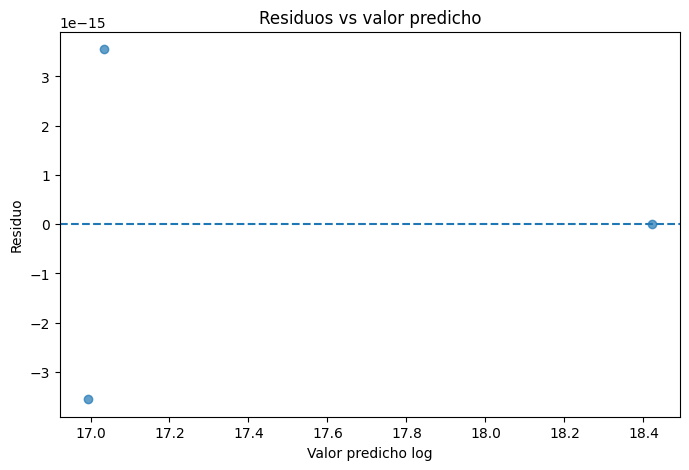

In [12]:
# ============================================================
# 11. Diagnóstico: heterocedasticidad y residuos
# ============================================================

train_diag = train.copy()
train_diag["pred_log_market_value"] = baseline_model.predict(train_diag)
train_diag["residual"] = train_diag[TARGET] - train_diag["pred_log_market_value"]

# Breusch-Pagan sobre el modelo sin cov_type robusto para disponer de exog/endog estándar
try:
    ols_plain = smf.ols(formula=formula_m2, data=train).fit()
    bp_test = het_breuschpagan(ols_plain.resid, ols_plain.model.exog)
    bp_labels = ["LM statistic", "LM p-value", "F statistic", "F p-value"]
    display(pd.DataFrame({"metric": bp_labels, "value": bp_test}))
except Exception as exc:
    print(f"No se pudo calcular Breusch-Pagan: {exc}")

plt.figure(figsize=(8, 5))
plt.scatter(train_diag["pred_log_market_value"], train_diag["residual"], alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Valor predicho log")
plt.ylabel("Residuo")
plt.title("Residuos vs valor predicho")
plt.show()

In [ ]:
vif_features = ["age", "age_squared", "log_minutes_played"] + available_performance
vif_df = train[vif_features].dropna().copy()

if len(vif_df) > 0 and vif_df.shape[1] >= 2:
    X_vif = sm.add_constant(vif_df)
    vif_table = pd.DataFrame({
        "variable": X_vif.columns,
        "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    })
    display(vif_table.sort_values("VIF", ascending=False))
else:
    print("No hay suficientes variables/filas para calcular VIF.")

,variable,VIF
1,age,inf
2,age_squared,inf
3,log_minutes_played,1.0721
0,const,0.0000
4,finishing_index,NaN
5,playmaking_index,NaN
6,progression_index,NaN
7,defensive_index,NaN


## 11. Estimación del valor esperado e Inefficiency Score

El output de negocio clave del baseline es el gap entre valor esperado y valor observado.

Definición:

$$
InefficiencyGap_{i,t} = \widehat{\log(MV)}_{i,t} - \log(MV_{i,t})
$$

Interpretación:

- gap positivo: el modelo estima un valor mayor que el observado → posible infravaloración;
- gap negativo: el mercado valora al jugador por encima de lo que explican sus variables observadas → posible sobrevaloración;
- gap cercano a cero: jugador alineado con el mercado.

Después se estandariza el gap para obtener un score comparable.

In [ ]:
scoring_df = df_model.copy()
scoring_df["pred_log_market_value"] = baseline_model.predict(scoring_df)
scoring_df["expected_market_value_eur"] = np.exp(scoring_df["pred_log_market_value"])

scoring_df["inefficiency_log_gap"] = scoring_df["pred_log_market_value"] - scoring_df[TARGET]
std_gap = scoring_df["inefficiency_log_gap"].std(ddof=0)

if pd.isna(std_gap) or std_gap == 0:
    scoring_df["inefficiency_score"] = 0.0
else:
    scoring_df["inefficiency_score"] = (
        scoring_df["inefficiency_log_gap"] - scoring_df["inefficiency_log_gap"].mean()
    ) / std_gap

scoring_df["market_value_gap_eur"] = scoring_df["expected_market_value_eur"] - scoring_df[OBSERVED_VALUE]
scoring_df["market_value_gap_pct"] = scoring_df["expected_market_value_eur"] / scoring_df[OBSERVED_VALUE] - 1

ranking_cols = [
    c for c in [
        "player_id", "player_name", "season", "season_start_year", "age", "position_group", LEAGUE_COL,
        OBSERVED_VALUE, "expected_market_value_eur", "market_value_gap_eur", "market_value_gap_pct",
        "inefficiency_log_gap", "inefficiency_score", "minutes_played", "is_low_minutes", "matching_confidence"
    ] if c is not None and c in scoring_df.columns
]

undervalued_ranking = scoring_df.sort_values("inefficiency_score", ascending=False)[ranking_cols]
display(undervalued_ranking.head(25))

ranking_path = OUTPUT_DIR / "undervalued_players_baseline.csv"
scoring_path = OUTPUT_DIR / "player_season_scoring_baseline.parquet"
undervalued_ranking.to_csv(ranking_path, index=False)
scoring_df.to_parquet(scoring_path, index=False)

print(f"Ranking guardado en: {ranking_path}")
print(f"Scoring completo guardado en: {scoring_path}")

,player_id,season,season_start_year,age,position_group,league_tm,market_value_eur,expected_market_value_eur,market_value_gap_eur,market_value_gap_pct,inefficiency_log_gap,inefficiency_score,minutes_played,is_low_minutes,matching_confidence
1,e1290c38854a1ba066c6bbcbe06b189a,2022-2023,2022,20,ATT,Austrian Bundesliga,24000000,"24,000,000.0000",0.0000,0.0000,0.0000,1.2247,1707,False,1.0000
2,10e37d554e6c4381fc8e017be60f77e1,2022-2023,2022,20,MID,LaLiga,100000000,"100,000,000.0000",0.0000,0.0000,0.0000,0.0000,2811,False,1.0000
0,575677ef98189b21f805574af1733c49,2022-2023,2022,19,DEF,Liga Portugal,25000000,"25,000,000.0000",-0.0000,-0.0000,-0.0000,-1.2247,2460,False,1.0000


Ranking guardado en: c:\Users\manue\Projects\market-value-football-tfm\data\outputs\models\undervalued_players_baseline.csv
Scoring completo guardado en: c:\Users\manue\Projects\market-value-football-tfm\data\outputs\models\player_season_scoring_baseline.parquet


## 12. Visualizaciones de negocio

Estas visualizaciones son útiles para la memoria y para la comunicación con perfiles no técnicos:

1. Valor observado vs valor esperado.
2. Distribución del `Inefficiency Score`.
3. Ranking de principales oportunidades.

La diagonal del primer gráfico representa alineación perfecta entre mercado y modelo. Los jugadores por encima de la diagonal presentan valor esperado superior al observado.

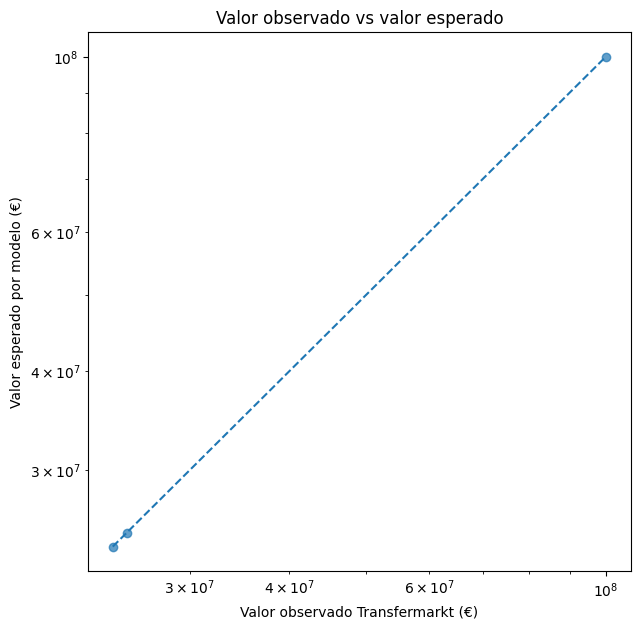

In [ ]:
plot_df = scoring_df.dropna(subset=[OBSERVED_VALUE, "expected_market_value_eur"]).copy()

plt.figure(figsize=(7, 7))
plt.scatter(plot_df[OBSERVED_VALUE], plot_df["expected_market_value_eur"], alpha=0.7)
min_v = min(plot_df[OBSERVED_VALUE].min(), plot_df["expected_market_value_eur"].min())
max_v = max(plot_df[OBSERVED_VALUE].max(), plot_df["expected_market_value_eur"].max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Valor observado Transfermarkt (€)")
plt.ylabel("Valor esperado por modelo (€)")
plt.title("Valor observado vs valor esperado")
plt.show()

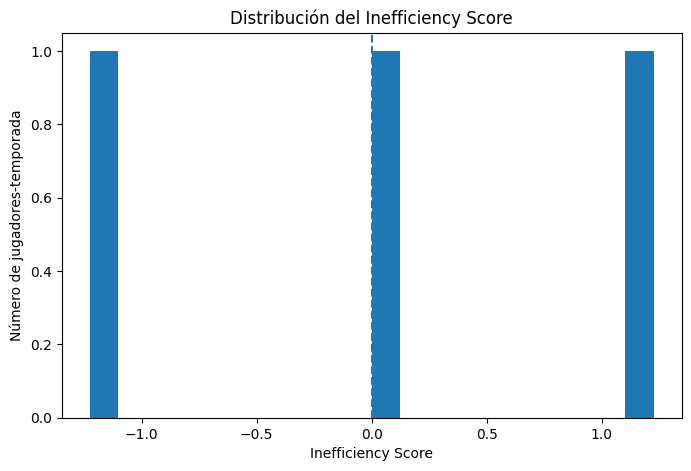

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(scoring_df["inefficiency_score"].dropna(), bins=20)
plt.axvline(0, linestyle="--")
plt.xlabel("Inefficiency Score")
plt.ylabel("Número de jugadores-temporada")
plt.title("Distribución del Inefficiency Score")
plt.show()

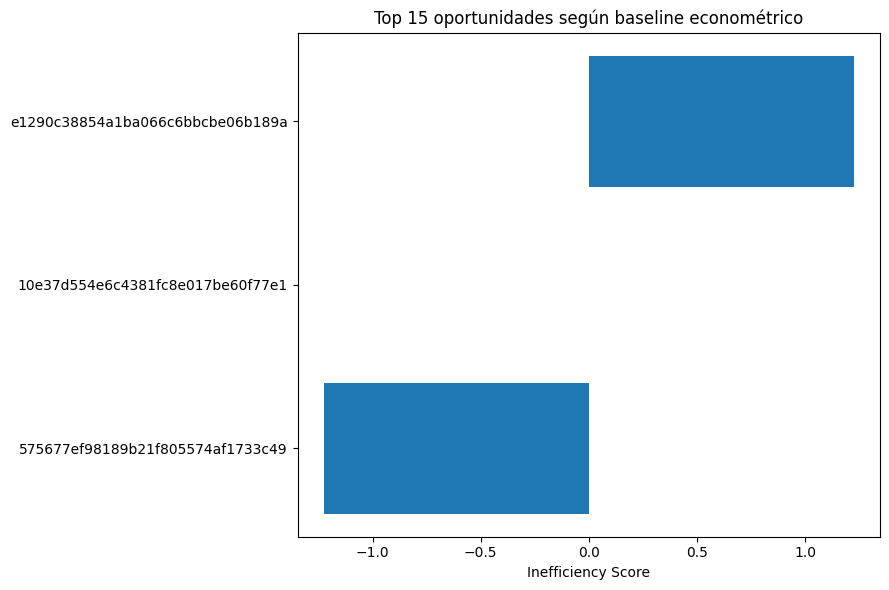

In [ ]:
top_n = 15
label_col = "player_name" if "player_name" in undervalued_ranking.columns else "player_id"
top = undervalued_ranking.head(top_n).iloc[::-1].copy()

plt.figure(figsize=(9, 6))
plt.barh(top[label_col].astype(str), top["inefficiency_score"])
plt.xlabel("Inefficiency Score")
plt.title(f"Top {top_n} oportunidades según baseline econométrico")
plt.tight_layout()
plt.show()

## 13. Lectura para scouting

El ranking no debe interpretarse como una orden automática de fichaje. Debe utilizarse como una **capa cuantitativa de priorización**.

Reglas de lectura recomendadas:

- `inefficiency_score` alto: jugador cuyo valor esperado supera al observado.
- `market_value_gap_eur` alto: oportunidad potencial en términos absolutos.
- `market_value_gap_pct` alto: oportunidad relativa, útil en jugadores baratos.
- `is_low_minutes = True`: alerta de baja robustez estadística.
- `matching_confidence` bajo: revisar manualmente el emparejamiento entre fuentes.

Criterio operativo:

> Un jugador es candidato prioritario si combina alto `Inefficiency Score`, edad adecuada, minutos suficientes, buena confianza de datos y encaje posicional con necesidades del club.

In [ ]:
scouting_df = scoring_df.copy()

conditions = [
    scouting_df["inefficiency_score"] >= 1.0,
    scouting_df["inefficiency_score"].between(0.0, 1.0, inclusive="left"),
    scouting_df["inefficiency_score"] < 0.0,
]
choices = ["priority_review", "monitor", "not_priority"]
scouting_df["scouting_bucket"] = np.select(conditions, choices, default="monitor")

# Penalización cualitativa si hay pocos minutos o baja confianza de matching.
if "is_low_minutes" in scouting_df.columns:
    scouting_df.loc[scouting_df["is_low_minutes"] == True, "scouting_bucket"] = "monitor_low_minutes"

if "matching_confidence" in scouting_df.columns:
    scouting_df.loc[scouting_df["matching_confidence"] < 0.8, "scouting_bucket"] = "manual_review_matching"

bucket_summary = (
    scouting_df
    .groupby("scouting_bucket")
    .agg(
        n=(TARGET, "size"),
        avg_inefficiency_score=("inefficiency_score", "mean"),
        avg_gap_eur=("market_value_gap_eur", "mean"),
    )
    .sort_values("avg_inefficiency_score", ascending=False)
)

display(bucket_summary)

bucket_path = OUTPUT_DIR / "scouting_buckets_baseline.csv"
scouting_df.to_csv(bucket_path, index=False)
print(f"Buckets de scouting guardados en: {bucket_path}")

,n,avg_inefficiency_score,avg_gap_eur
scouting_bucket,,,
priority_review,1,1.2247,0.0000
monitor,1,0.0000,0.0000
not_priority,1,-1.2247,-0.0000


Buckets de scouting guardados en: c:\Users\manue\Projects\market-value-football-tfm\data\outputs\models\scouting_buckets_baseline.csv


## 14. Limitaciones del baseline

Este modelo es una primera aproximación y debe documentarse con precisión en la memoria:

### 1. No es un modelo causal

El coeficiente de una variable de rendimiento no debe interpretarse como impacto causal sobre el valor. Puede haber causalidad inversa y variables omitidas.

### 2. Variables omitidas relevantes

El mercado incorpora información no incluida en el dataset:

- duración contractual;
- salario;
- agente;
- historial de lesiones;
- internacionalidades;
- reputación mediática;
- fortaleza económica del club comprador/vendedor.

### 3. Endogeneidad

Minutos, rendimiento y valor pueden estar determinados conjuntamente por talento latente, club, entrenador y exposición mediática.

### 4. Multicolinealidad

Las métricas de rendimiento suelen estar correlacionadas. Por eso se usan índices agregados, pero el problema debe monitorizarse.

### 5. Sesgo de muestra

Si el dataset actual es reducido o de prueba, los resultados deben interpretarse como validación técnica del pipeline, no como inferencia deportiva definitiva.

### 6. Efectos fijos de jugador

Los efectos fijos de jugador son útiles para robustez longitudinal, pero reducen la utilidad de scouting cross-sectional porque absorben características persistentes del propio jugador.

## 15. Próximos pasos

Tras este baseline econométrico, los siguientes pasos naturales son:

1. Ampliar dataset real multi-temporada y multi-liga.
2. Incorporar métricas avanzadas de Understat: `xg_per90`, `xa_per90`.
3. Añadir variables de trayectoria: evolución de minutos, rendimiento y valor.
4. Comparar el baseline con modelos ML: Random Forest, XGBoost/LightGBM.
5. Evaluar con validación temporal estricta.
6. Construir `Growth Score` y combinarlo con `Inefficiency Score`.
7. Diseñar un ranking final con `Confidence Score` para uso por scouting.

La secuencia metodológica recomendada es:

```text
Baseline econométrico → Modelos ML → Growth Model → Scoring final → Ranking de oportunidades
```

In [3]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

panel_path = PROJECT_ROOT / "data" / "processed" / "player_season_panel.parquet"

df = pd.read_parquet(panel_path)

print("Path:", panel_path)
print("Rows:", len(df))
print("Columns:")
print(df.columns.tolist())

df.head()

Path: c:\Users\manue\Projects\market-value-football-tfm\data\processed\player_season_panel.parquet
Rows: 3
Columns:
['player_name_tm', 'season', 'age', 'position_tm', 'club', 'league_tm', 'market_value_eur', 'player_id', 'season_start_year', 'position_group', 'log_market_value_eur', 'normalized_name', 'player_name_fbref', 'squad', 'league_fbref', 'position_fbref', 'minutes_played', 'goals_per90', 'assists_per90', 'shots_per90', 'progressive_passes_per90', 'progressive_carries_per90', 'tackles_per90', 'interceptions_per90', 'matching_status', 'name_similarity', 'matching_confidence']


,player_name_tm,season,age,position_tm,club,league_tm,market_value_eur,player_id,season_start_year,position_group,...,goals_per90,assists_per90,shots_per90,progressive_passes_per90,progressive_carries_per90,tackles_per90,interceptions_per90,matching_status,name_similarity,matching_confidence
0,Antonio Silva,2022-2023,19,Centre-Back,Benfica,Liga Portugal,25000000,575677ef98189b21f805574af1733c49,2022,DEF,...,0.11,0.00,0.61,4.92,0.73,1.39,1.71,matched,1.0,1.0
1,Benjamin Sesko,2022-2023,20,Centre-Forward,RB Salzburg,Austrian Bundesliga,24000000,e1290c38854a1ba066c6bbcbe06b189a,2022,ATT,...,0.84,0.16,3.01,1.04,1.37,0.51,0.22,matched,1.0,1.0
2,Pedri,2022-2023,20,Central Midfield,FC Barcelona,LaLiga,100000000,10e37d554e6c4381fc8e017be60f77e1,2022,MID,...,0.19,0.03,1.15,7.21,2.42,1.78,1.21,matched,1.0,1.0
